In [126]:
from sklearn.datasets import make_regression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

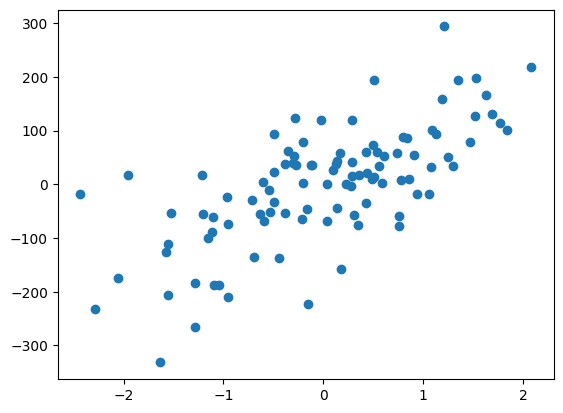

In [127]:
X,y = make_regression(n_samples=100, n_features=1,n_informative=1,n_targets=1,noise=80)
plt.scatter(X,y)

In [128]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [129]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)
m = lr.coef_
print(lr.coef_)
print(lr.intercept_)
y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
print(r2_score(y_test,y_pred))

[77.69346254]
0.8091000587785433
0.5626979144428996


In [130]:
class GDRegressor:
    def __init__(self,learning_rate,epochs):
        self.m = m
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,X,y):
        for i in range(self.epochs):
            loss_slope = -2 * np.sum(y -self.m*X.ravel() - self.b)
            self.b= self.b - (self.lr * loss_slope)
            print(loss_slope,self.b)
            # y_pred = self.m*X + self.b
        print(self.b)



In [131]:
gd = GDRegressor(0.001,100)

In [132]:
gd.fit(X,y)

-23595.73092699077 -96.40426907300923
-18876.58474159262 -77.52768433141661
-15101.267793274092 -62.42641653814252
-12081.014234619272 -50.345402303523244
-9664.811387695421 -40.68059091582782
-7731.849110156336 -32.94874180567149
-6185.479288125071 -26.763262517546416
-4948.383430500055 -21.81487908704636
-3958.706744400045 -17.856172342646317
-3166.965395520036 -14.689206947126282
-2533.5723164160286 -12.155634630710253
-2026.8578531328235 -10.128776777577428
-1621.4862825062582 -8.507290495071171
-1297.1890260050068 -7.2101014690661644
-1037.7512208040052 -6.172350248262159
-830.200976643204 -5.342149271618955
-664.1607813145631 -4.677988490304392
-531.3286250516505 -4.146659865252741
-425.0629000413204 -3.721596965211421
-340.0503200330567 -3.3815466451783642
-272.0402560264448 -3.1095063891519192
-217.63220482115634 -2.8918741843307627
-174.10576385692468 -2.717768420473838
-139.28461108553975 -2.578483809388298
-111.42768886843257 -2.4670561205198656
-89.14215109474571 -2.3779139

In [133]:
class GDRegressor2:
    def __init__(self,learning_rate,epochs):
        self.m = m
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,X,y):
        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(y -self.m*X.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y -self.m*X.ravel() - self.b)*X.ravel())
            self.b= self.b - (self.lr * loss_slope_b)
            self.m= self.m - (self.lr * loss_slope_m)
            # print(loss_slope_b,self.b)
            # y_pred = self.m*X + self.b
        print(self.b,self.m)

    def predict(self,X):
        return self.m * X + self.b



In [134]:
gd2 = GDRegressor2(0.001,100)
gd2.fit(X_train,y_train)

0.8090958507523364 [77.69346516]


In [135]:
gd2.predict(X_test)

array([[ 143.61535418],
       [ -22.66196226],
       [  40.39560649],
       [   8.01404127],
       [ -48.80506211],
       [ -15.1600398 ],
       [  34.89458879],
       [-159.14997374],
       [ -11.88882303],
       [  -8.31373739],
       [ -45.97041768],
       [ 114.87931655],
       [ -84.50496966],
       [-121.8523894 ],
       [  -8.72115982],
       [  65.9287676 ],
       [  14.87201157],
       [  11.01188949],
       [ -45.61365169],
       [ -40.49142707]])

In [136]:
y_pred2 = lr.predict(X_test)
print(r2_score(y_test,y_pred2))

0.5626979144428996
